Bollywood movie analysis

#### Meta-Data of the Bollywood Dataset:

###### SINo - Identifier for the movies.
###### Release Date - Date on which the movie was released.
###### MovieName - Name of the movie.
###### ReleaseTime - Mentions special time of release. LW (Long weekend), FS (Festive Season), HS (Holiday Season), N (Normal).
###### Genre – Genre of the film such as Romance, Thriller, Action, Comedy, etc
###### Budget – Movie creation budget
###### BoxOfficeCollection – Box office collection
###### YoutubeViews – Number of views of the YouTube trailers
###### YoutubeLikes – Number of likes of the YouTube trailers
###### YoutubeDislikes – Number of dislikes of the YouTube trailers

In [1]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("subhranilpaul/bollywoodcsv")

print("Path to dataset files:", path)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\LENOVO\.cache\kagglehub\datasets\subhranilpaul\bollywoodcsv\versions\1


In [3]:
files = os.listdir(path)
print("Files in the dataset:", files)

Files in the dataset: ['bollywood.csv']


In [4]:
df = pd.read_csv(os.path.join(path, 'bollywood.csv'))
df.head(10)

,SlNo,ReleaseDate,MovieName,ReleaseTime,Genre,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
0,1,18-Apr-14,2States,LW,Romance,36,104.00,8576361,26622,2527
1,2,4-Jan-13,TableNo.21,N,Thriller,10,12.00,1087320,1129,137
2,3,18-Jul-14,AmitSahniKiList,N,Comedy,10,4.00,572336,586,54
3,4,4-Jan-13,RajdhaniExpress,N,Drama,7,0.35,42626,86,19
4,5,4-Jul-14,BobbyJasoos,N,Comedy,18,10.80,3113427,4512,1224
5,6,30-May-14,Citylights,HS,Drama,7,35.00,1076591,1806,84
6,7,19-Sep-14,Daawat-E-Ishq,N,Comedy,30,24.60,3905050,8315,1373
7,8,11-Jan-13,MatruKiBijleeKaMandola,N,Comedy,33,40.00,2435283,4326,647
8,9,10-Jan-14,DedhIshqiya,LW,Comedy,31,27.00,2333067,2436,591
9,10,11-Jan-13,Gangoobai,N,Drama,2,0.01,4354,1,1


In [5]:
df.shape

(149, 10)

How many movies were released in each Release Time? Sort number of releases in Release Time in descending order.

In [6]:
# finding the number of movies by release time sorted in the descending order
df.groupby('ReleaseTime').size().sort_values(ascending=False)

ReleaseTime
N     99
HS    18
FS    17
LW    15
dtype: int64

Which genre had highest number of releases during the Festive Season?

In [7]:
df.Genre.value_counts()

Genre
Comedy      36
Drama       35
Thriller    29
Romance     25
Action      24
Name: count, dtype: int64

In [8]:
df.Genre.unique().tolist()

['Romance', 'Thriller', 'Comedy', 'Drama', 'Action']

In [9]:
# formatting the genre column
df.Genre = df.Genre.str.strip()

# finding the genre with the highest number of release during the festive season
df[df.ReleaseTime=='FS'].Genre.value_counts()

Genre
Drama       4
Thriller    4
Action      3
Romance     3
Comedy      3
Name: count, dtype: int64

How many movies in each genre got released in different release times like long weekend, festive season, etc.

In [10]:
# cross tab between Genre and ReleaseTime
pd.crosstab(df.Genre, df.ReleaseTime)

ReleaseTime,FS,HS,LW,N
Genre,,,,
Action,3,3,3,15
Comedy,3,5,5,23
Drama,4,6,1,24
Romance,3,3,4,15
Thriller,4,1,2,22


In which year were highest number movie released?

In [11]:
# finding the year when the highest number of movies were released

#converting Release Date into datetime data type
df['Release_Date'] = pd.to_datetime(df['ReleaseDate'])

# creating a year column to extract the date from the column Release Date
df['Year'] = df['Release_Date'].dt.year

# Finding the year when the maximum number of movies were released
df.Year.value_counts()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22268\2843452402.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Release_Date'] = pd.to_datetime(df['ReleaseDate'])


Year
2014    70
2013    67
2015    12
Name: count, dtype: int64

Which month of the year typically sees most releases of high budgeted movies, that is, movies with budget of 30 crore or more?

In [12]:
df.columns

Index(['SlNo', 'ReleaseDate', 'MovieName', 'ReleaseTime', 'Genre', 'Budget',
       'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes',
       'YoutubeDislikes', 'Release_Date', 'Year'],
      dtype='str')

In [13]:
# finding the month which sees maximum number of highh budget movies
df[df.Budget>=30]['Release_Date'].dt.month.value_counts()

Release_Date
2     8
8     7
1     6
11    6
6     5
7     5
9     4
10    4
4     3
3     3
5     3
12    2
Name: count, dtype: int64

Which are the top 10 flop movies with minimum return on investment(ROI)

In [14]:
df.columns

Index(['SlNo', 'ReleaseDate', 'MovieName', 'ReleaseTime', 'Genre', 'Budget',
       'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes',
       'YoutubeDislikes', 'Release_Date', 'Year'],
      dtype='str')

In [15]:
# Finding the top 10 flop movies with minimum ROI
# Creating the rOI
df['ROI'] = (df.BoxOfficeCollection - df.Budget)/df.Budget

#  sorting the values and displaying the top 10 flop movies
df.sort_values(by='ROI').MovieName[:10]

9              Gangoobai
15               Bandook
53               SonaSpa
3        RajdhaniExpress
49     KyaDilliKyaLahore
121               Satya2
67           PuraniJeans
103         SamratandCo.
30             Heartless
102              Kaanchi
Name: MovieName, dtype: str

 Do the movies have higher ROI if they get released on festive seasons or long weekend? Calculate the average ROI for different release times.

In [16]:
df.groupby(by='ReleaseTime').ROI.mean()

ReleaseTime
FS    0.973853
HS    0.850867
LW    1.127205
N     0.657722
Name: ROI, dtype: float64

 Is there a correlation between box office collection and YouTube likes? Is the correlation positive or negative?

In [17]:
# correlation between BoxOfficeCollection and YoutubeLikes
corr = df[['BoxOfficeCollection', 'YoutubeLikes']].corr()
corr

,BoxOfficeCollection,YoutubeLikes
BoxOfficeCollection,1.000000,0.682517
YoutubeLikes,0.682517,1.000000


Which genre of movies typically sees more YouTube views? Draw boxplots for each genre of movies to compare.

<Axes: xlabel='Genre', ylabel='YoutubeViews'>

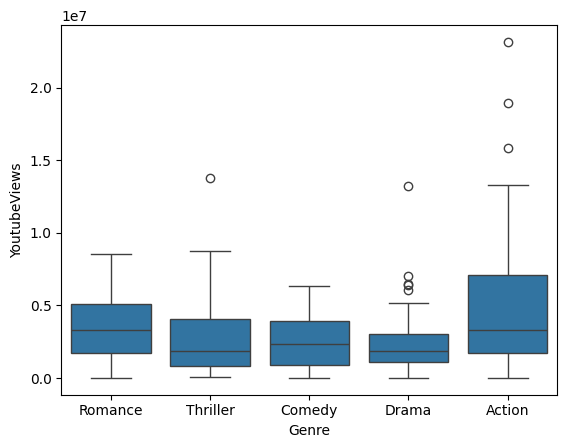

In [18]:
#  comparing Youtube views of genre by plotting boxplots
sns.boxplot(x='Genre', y='YoutubeViews', data=df)

 Which of the variables among Budget, BoxOfficeCollection, YoutubeView, YoutubeLikes, YoutubeDislikes are highly correlated?

In [20]:
df.columns

Index(['SlNo', 'ReleaseDate', 'MovieName', 'ReleaseTime', 'Genre', 'Budget',
       'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes',
       'YoutubeDislikes', 'Release_Date', 'Year', 'ROI'],
      dtype='str')

<Axes: >

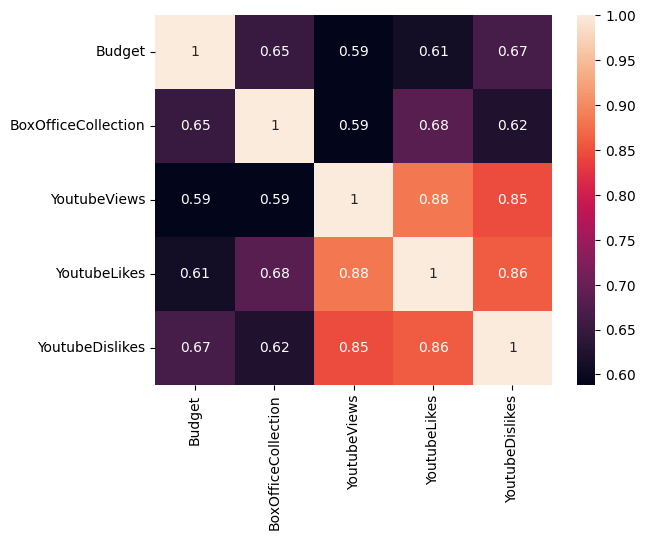

In [21]:
# Correlation heatmap for variables Budget, BoxOfficeCollection, YoutubeView, YoutubeLikes, YoutubeDislikes
# Calculating correlation values between the variables
corr = df[['Budget', 'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes', 'YoutubeDislikes']].corr()

# plotting a heatmap to visualize the correlation
sns.heatmap(corr, annot=True)

 During 2013−2015 period, highlight the genre of movies and their box office collection? Visualize with best fit graph.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22268\354759797.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Year', y='BoxOfficeCollection', hue='Genre', data=df, ci=None)


<Axes: xlabel='Year', ylabel='BoxOfficeCollection'>

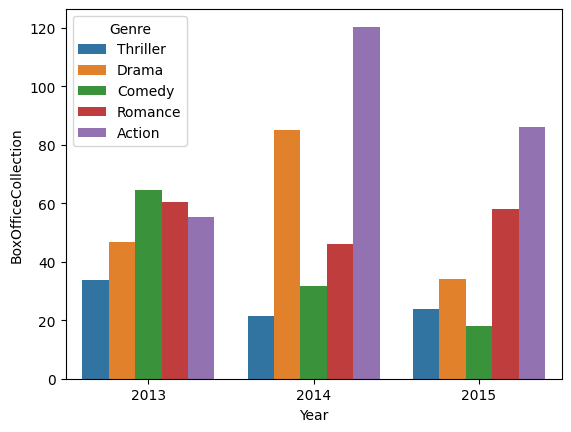

In [22]:
# plotting a barplot to highlight the genre of movies and their box office collection
sns.barplot(x='Year', y='BoxOfficeCollection', hue='Genre', data=df, ci=None)

During 2013−2015, find the number of movies released in every year. Also, visualize with best fit graph.

In [23]:
# finding number of movies released in every year
df.Year.value_counts()

Year
2014    70
2013    67
2015    12
Name: count, dtype: int64

<Axes: xlabel='Year', ylabel='count'>

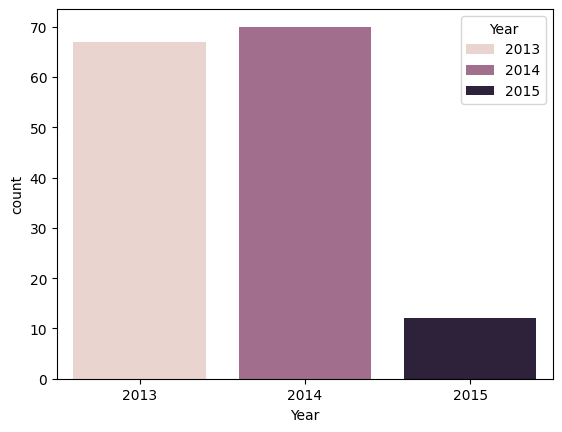

In [25]:
sns.countplot(x='Year', data=df, hue='Year')

Find the distribution of movie budget for every Genre

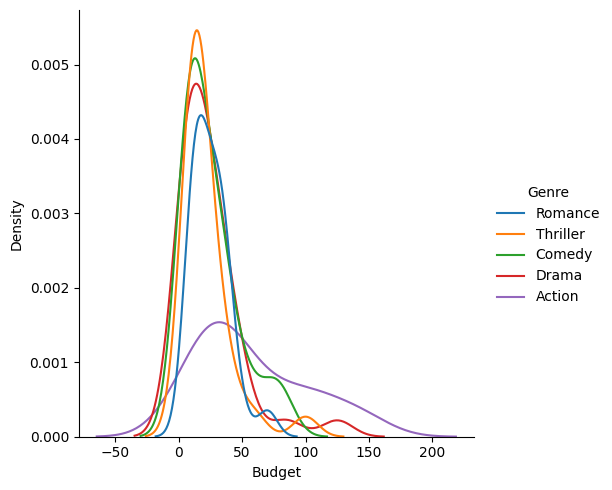

In [26]:
# plotting a distplot to visualize the distribution of Budget Genre-wise
sns.displot(x='Budget', data=df, kind='kde', hue='Genre')

During 2013−2015, Visualize the number of YouTube likes and YouTube dislikes every year. Also, visualize with best fit graph.

In [27]:
df.columns

Index(['SlNo', 'ReleaseDate', 'MovieName', 'ReleaseTime', 'Genre', 'Budget',
       'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes',
       'YoutubeDislikes', 'Release_Date', 'Year', 'ROI'],
      dtype='str')

In [28]:
df.groupby(by='Year').YoutubeLikes.sum()

Year
2013    324180
2014    710142
2015    139431
Name: YoutubeLikes, dtype: int64

In [29]:
df.groupby(by='Year').YoutubeDislikes.sum()

Year
2013     58156
2014    104682
2015     17127
Name: YoutubeDislikes, dtype: int64

In [30]:
likes = [324180, 710142, 139431]
dislikes = [58156, 104682, 17127]
year = ['2013', '2014', '2015']

In [31]:
#convert the arrays into dataframe
compare = pd.DataFrame({'likes':likes, 'dislikes':dislikes, 'year':year})
compare

,likes,dislikes,year
0,324180,58156,2013
1,710142,104682,2014
2,139431,17127,2015


<Axes: >

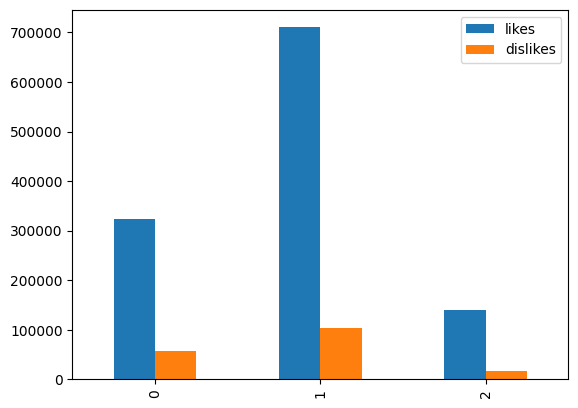

In [32]:
compare.plot.bar()